### CONEXION DDBB OLIST

In [1]:
%pip install PyMySQL
from sqlalchemy import create_engine, text
import ssl

## CONEXION BBDD MYSQL ##
DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

# Crear engine apuntando a la base 'olist'
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}} 
)

# tablas 'olist'
with engine.connect() as conn:
    tables = conn.execute(text("SHOW TABLES")).fetchall()
    tables = [row[0] for row in tables]   # convertir a lista simple de strings
    
    print("Tablas en la base 'olist':")
    for t in tables:
        print("-", t)



Note: you may need to restart the kernel to use updated packages.
Tablas en la base 'olist':
- dash_olist_categorias_resumen
- dash_olist_demorados
- dash_olist_sellers
- dash_olist_states
- dash_olist_ventas_meses
- dash_sentiment_analysis
- distribucion_pedidos
- olist_customers_dataset
- olist_geolocation_dataset
- olist_order_items_dataset
- olist_order_payments_dataset
- olist_order_reviews_dataset
- olist_orders_dataset
- olist_products_dataset
- olist_sellers_dataset
- pedidos_por_tiempo
- product_category_name_translation


In [6]:
import pandas as pd
from IPython.display import display, Markdown

# Cargar los datos desde la base de datos SQL
query = """
SELECT 
    pct.product_category_name_english AS product_category_name,
    i.price,
    i.seller_id,
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp,
    r.review_score
FROM olist_order_items_dataset i
LEFT JOIN olist_products_dataset p
    ON i.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
LEFT JOIN olist_orders_dataset o
    ON i.order_id = o.order_id
LEFT JOIN olist_customers_dataset c
    ON o.customer_id = c.customer_id
LEFT JOIN olist_order_reviews_dataset r
    ON o.order_id = r.order_id
WHERE o.order_status <> 'canceled'
"""
df = pd.read_sql_query(query, con=engine)

# Convertir la fecha de compra a formato datetime
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")

# Filtrar solo los años 2017 y 2018
df = df[df["order_purchase_timestamp"].dt.year.isin([2017, 2018])]

# Crear una columna con el formato de mes (AAAA-MM)
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Agrupar por categoría y mes para calcular ventas y otras métricas
group_cols = ["product_category_name", "order_month"]

ventas_mensuales = (
    df.groupby(group_cols, dropna=False)
      .agg(
          total_sales=("price", "sum"),
          orders_qty=("order_id", "nunique"),
          unique_sellers=("seller_id", "nunique"),
          customers=("customer_unique_id", "nunique"),
          avg_score=("review_score", "mean")
      )
      .reset_index()
)

# Calcular clientes que repiten compras dentro del mismo mes
repeat_customers = (
    df.groupby(group_cols + ["customer_unique_id"])
      .agg(order_count=("order_id", "nunique"))
      .reset_index()
)

# Filtrar los que tienen más de un pedido (recurrentes)
repeat_customers = (
    repeat_customers[repeat_customers["order_count"] > 1]
    .groupby(group_cols)
    .agg(repeat_customers=("customer_unique_id", "nunique"))
    .reset_index()
)

# Unir los resultados de ventas con los clientes recurrentes
merged_monthly = ventas_mensuales.merge(repeat_customers, on=group_cols, how="left").fillna({"repeat_customers": 0})

# Ordenar los datos por categoría y mes para facilitar la lectura
merged_monthly = merged_monthly.sort_values(["product_category_name", "order_month"])

# Obtener las 10 categorías con mayores ventas totales
top_cats = (
    merged_monthly.groupby("product_category_name")["total_sales"].sum().nlargest(10).index
)

# Mostrar los resultados en tabla (solo las categorías del top 10)
display(Markdown("#### Ventas mensuales por categoría (Top 10 categorías – 2017-2018)"))
display(
    merged_monthly[merged_monthly["product_category_name"].isin(top_cats)]
    .head(50)
)


#### Ventas mensuales por categoría (Top 10 categorías – 2017-2018)

,product_category_name,order_month,total_sales,orders_qty,unique_sellers,customers,avg_score,repeat_customers
82,auto,2017-01,5168.83,29,15,29,NaN,0.0
83,auto,2017-02,12657.68,76,34,76,NaN,0.0
84,auto,2017-03,13697.98,71,30,71,NaN,0.0
85,auto,2017-04,15548.17,81,38,81,NaN,0.0
86,auto,2017-05,17771.74,103,41,102,NaN,1.0
87,auto,2017-06,29370.70,102,28,102,NaN,0.0
88,auto,2017-07,14091.75,105,41,103,NaN,2.0
89,auto,2017-08,19971.21,132,48,132,NaN,0.0
90,auto,2017-09,14544.67,97,40,97,NaN,0.0
91,auto,2017-10,21479.29,131,49,129,5.000000,2.0


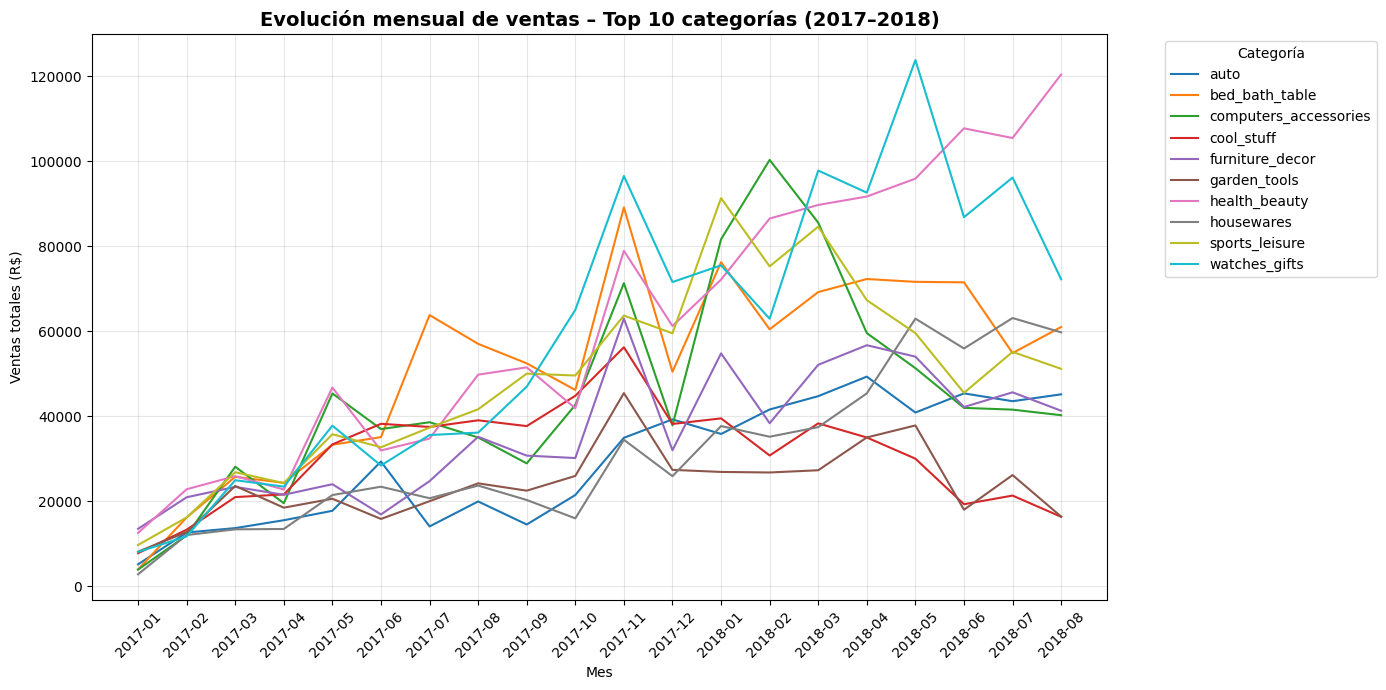

In [ ]:
import matplotlib.pyplot as plt

# Seleccionar las 10 categorías con mayores ventas totales
top10_cats = (
    merged_monthly.groupby("product_category_name")["total_sales"]
    .sum()
    .nlargest(10)
    .index
)

# Filtrar solo los datos de esas categorías
top10_df = merged_monthly[merged_monthly["product_category_name"].isin(top10_cats)]

# Ordenar los registros por mes para que la evolución se vea bien en el gráfico
top10_df = top10_df.sort_values("order_month")

# Crear una tabla pivote con meses como filas y categorías como columnas
pivot_chart = top10_df.pivot_table(
    index="order_month",
    columns="product_category_name",
    values="total_sales",
    aggfunc="sum"
).fillna(0)

# Crear el gráfico de líneas
plt.figure(figsize=(14, 7))

# Dibujar una línea por cada categoría
for cat in pivot_chart.columns:
    plt.plot(pivot_chart.index, pivot_chart[cat], label=cat)

# Personalizar el gráfico
plt.title("Evolución mensual de ventas – Top 10 categorías (2017–2018)", fontsize=14, weight="bold")
plt.xlabel("Mes")
plt.ylabel("Ventas totales (R$)")
plt.xticks(rotation=45)
plt.legend(title="Categoría", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
import pandas as pd
from IPython.display import display, Markdown

# Cargar los datos desde SQL (incluye estado del pedido)
query_status = """
SELECT 
    pct.product_category_name_english AS product_category_name,
    i.order_id,
    o.order_purchase_timestamp,
    o.order_status
FROM olist_order_items_dataset i
LEFT JOIN olist_products_dataset p
    ON i.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
LEFT JOIN olist_orders_dataset o
    ON i.order_id = o.order_id
"""
df_status = pd.read_sql_query(query_status, con=engine)

# Convertir la fecha de compra a tipo datetime
df_status["order_purchase_timestamp"] = pd.to_datetime(df_status["order_purchase_timestamp"], errors="coerce")

# Filtrar solo los años 2017 y 2018
df_status = df_status[df_status["order_purchase_timestamp"].dt.year.isin([2017, 2018])]

# Crear columna con el formato de mes (AAAA-MM)
df_status["order_month"] = df_status["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Crear columnas binarias para marcar pedidos cancelados o no disponibles
df_status["canceled_flag"] = (df_status["order_status"] == "canceled").astype(int)
df_status["unavailable_flag"] = (df_status["order_status"] == "unavailable").astype(int)

# Agrupar los datos por categoría y mes para contar cuántos pedidos hay de cada tipo
status_monthly = (
    df_status.groupby(["product_category_name", "order_month"], dropna=False)
      .agg(
          canceled_orders=("canceled_flag", "sum"),
          unavailable_orders=("unavailable_flag", "sum")
      )
      .reset_index()
)

# Calcular una columna con el total combinado de cancelados + no disponibles
status_monthly["total_canceled_unavailable"] = (
    status_monthly["canceled_orders"] + status_monthly["unavailable_orders"]
)

# Ordenar el resultado por categoría y mes
status_monthly = status_monthly.sort_values(["product_category_name", "order_month"])

# Mostrar el resultado en formato tabla
display(Markdown("#### Pedidos cancelados, indisponibles y total por categoría y mes (2017–2018)"))
display(status_monthly.head(20))


#### Pedidos cancelados, indisponibles y total por categoría y mes (2017–2018)

,product_category_name,order_month,canceled_orders,unavailable_orders,total_canceled_unavailable
0,agro_industry_and_commerce,2017-01,0,0,0
1,agro_industry_and_commerce,2017-02,0,0,0
2,agro_industry_and_commerce,2017-03,0,0,0
3,agro_industry_and_commerce,2017-05,0,0,0
4,agro_industry_and_commerce,2017-06,0,0,0
5,agro_industry_and_commerce,2017-07,0,0,0
6,agro_industry_and_commerce,2017-08,0,0,0
7,agro_industry_and_commerce,2017-09,0,0,0
8,agro_industry_and_commerce,2017-10,0,0,0
9,agro_industry_and_commerce,2017-11,0,0,0


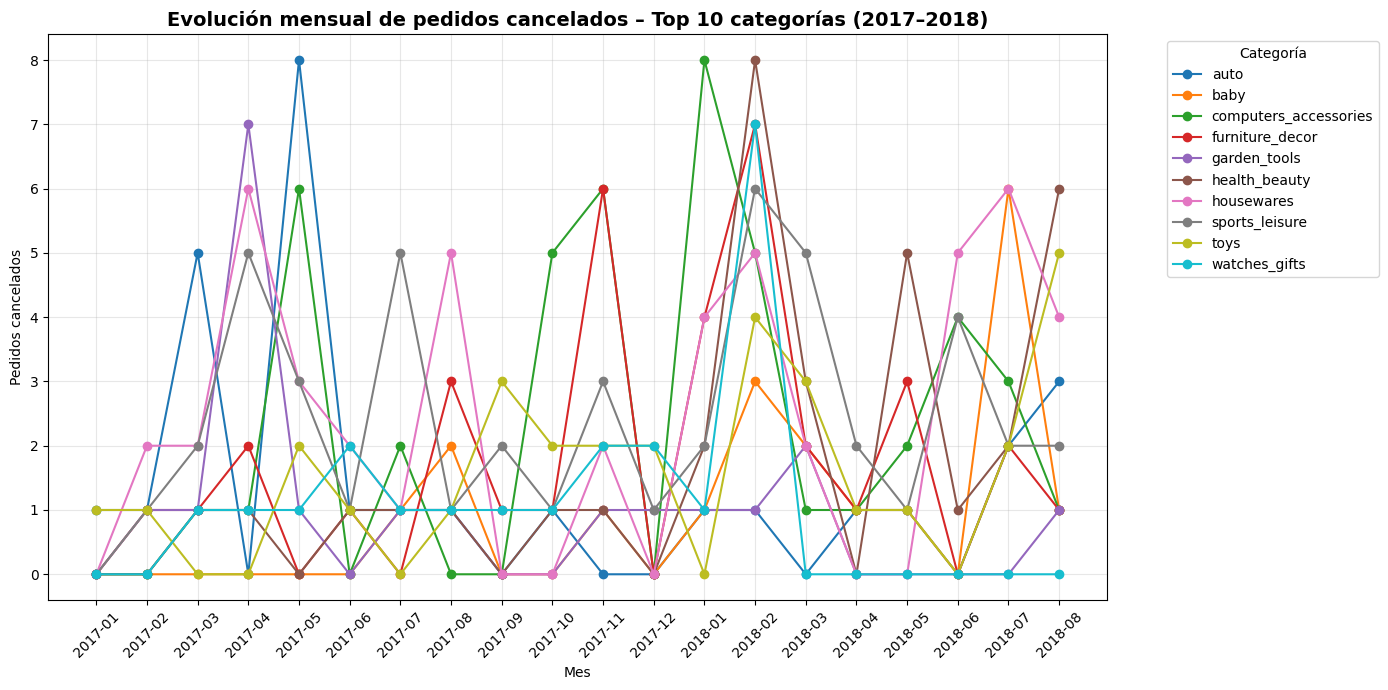

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegurarse de tener el DataFrame con cancelaciones
# Si ya tienes 'status_monthly' de antes, lo usamos directamente
# Este DataFrame debería tener: product_category_name, order_month, canceled_orders, unavailable_orders, etc.

# Crear un dataset solo con pedidos cancelados
canceled_monthly = status_monthly[["product_category_name", "order_month", "canceled_orders"]].copy()

# Calcular las 10 categorías con más pedidos cancelados (total 2017–2018)
top10_cancel = (
    canceled_monthly.groupby("product_category_name")["canceled_orders"]
    .sum()
    .nlargest(10)
    .index
)

# Filtrar el DataFrame para quedarse solo con esas categorías
top10_canceled_df = canceled_monthly[canceled_monthly["product_category_name"].isin(top10_cancel)]

# Ordenar los registros por mes (para que las líneas del gráfico estén en orden temporal)
top10_canceled_df = top10_canceled_df.sort_values("order_month")

# Crear una tabla pivote para graficar: filas = meses, columnas = categorías
pivot_cancel_chart = top10_canceled_df.pivot_table(
    index="order_month",
    columns="product_category_name",
    values="canceled_orders",
    aggfunc="sum"
).fillna(0)

# Crear la figura del gráfico
plt.figure(figsize=(14, 7))

# Dibujar una línea por cada categoría
for cat in pivot_cancel_chart.columns:
    plt.plot(pivot_cancel_chart.index, pivot_cancel_chart[cat], marker="o", label=cat)

# Personalización del gráfico
plt.title("Evolución mensual de pedidos cancelados – Top 10 categorías (2017–2018)", fontsize=14, weight="bold")
plt.xlabel("Mes")
plt.ylabel("Pedidos cancelados")
plt.xticks(rotation=45)
plt.legend(title="Categoría", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)

# Ajustar diseño y mostrar resultado
plt.tight_layout()
plt.show()


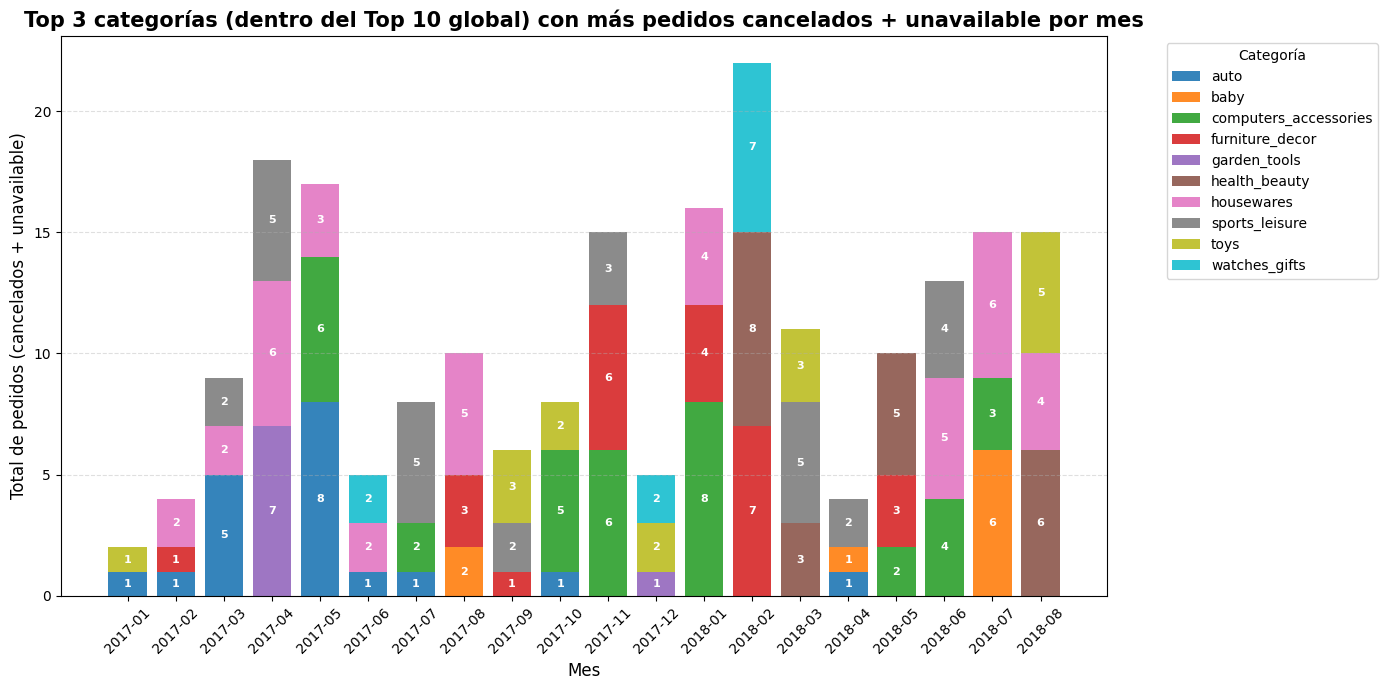

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calcular una columna con el total combinado de cancelados + no disponibles
status_monthly["total_canceled_unavailable"] = (
    status_monthly["canceled_orders"] + status_monthly["unavailable_orders"]
)

# Seleccionar las 10 categorías con mayor volumen total de cancelaciones (2017–2018)
top10_cats = (
    status_monthly.groupby("product_category_name")["total_canceled_unavailable"]
    .sum()
    .nlargest(10)
    .index
)

# Filtrar el dataset para quedarse solo con esas 10 categorías
status_top10 = status_monthly[status_monthly["product_category_name"].isin(top10_cats)]

# Dentro de esas 10, seleccionar las 3 categorías más afectadas en cada mes
top3_per_month = (
    status_top10
    .sort_values(["order_month", "total_canceled_unavailable"], ascending=[True, False])
    .groupby("order_month")
    .head(3)
)

# Crear un pivot con los meses como índice y las categorías como columnas
pivot_top3 = top3_per_month.pivot_table(
    index="order_month",
    columns="product_category_name",
    values="total_canceled_unavailable",
    aggfunc="sum"
).fillna(0)

# Crear el gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(14, 7))

bottom = np.zeros(len(pivot_top3))
color_map = plt.cm.tab10(np.linspace(0, 1, len(pivot_top3.columns)))

# Dibujar una barra por categoría (apiladas)
for i, cat in enumerate(pivot_top3.columns):
    bars = ax.bar(
        pivot_top3.index,
        pivot_top3[cat],
        bottom=bottom,
        label=cat,
        color=color_map[i % len(color_map)],
        alpha=0.9
    )
    bottom += pivot_top3[cat].values

    # Añadir etiquetas con los valores dentro de las barras
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{int(height):,}",
                ha="center",
                va="center",
                fontsize=8,
                color="white",
                fontweight="bold"
            )

# Personalizar el gráfico
ax.set_title(
    "Top 3 categorías (dentro del Top 10 global) con más pedidos cancelados + unavailable por mes",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Mes", fontsize=12)
ax.set_ylabel("Total de pedidos (cancelados + unavailable)", fontsize=12)

# Evitar warning: definir ticks antes de las etiquetas
ax.set_xticks(range(len(pivot_top3.index)))
ax.set_xticklabels(pivot_top3.index, rotation=45)

ax.legend(title="Categoría", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Ajustar el diseño y mostrar el resultado
plt.tight_layout()
plt.show()
